# No Derivation, No Relation — Supervised `located_in` Extractor + Closure Certificate

**iter-10 `S_supervised`: a net-utility boundary test for the closure certificate.**

This demo accompanies the experiment *"Supervised `located_in` extractor vs closure
certificate: a net-utility boundary test."* The research pipeline turns short professionally
written documents (Re-DocRED Wikipedia articles, ~3000 chars) into **first-order
`located_in` / `contains` facts** and reasons over them symbolically with a **forward
least-fixpoint closure** — the *"no derivation, no relation"* certificate that is
**hallucination-safe by construction**: if no containment path can be *derived*, it
**abstains** instead of inventing a relation.

The full pipeline (heavy: trains a calibrated GBDT + fine-tunes `deberta-v3-small`
doc-disjoint on the natural Re-DocRED corpus, then replays 6 confident-wrong competitors
byte-identical from a SHA-256 cache) is **not re-run here**. Instead this demo loads the
**precomputed predictions, frontier, and worked traces** and re-derives the headline result,
while running the **genuine closure-certificate engine** (`kinship.py`, reused VERBATIM) live
on two worked documents.

**What the demo shows**
1. **The symbolic certificate** (`kinship.py` forward-closure) on a worked document — it
   *deduces* a held-out 2-hop `located_in` relation and prints the **human-auditable
   trace-graph**, and on a sibling pair it **abstains** (no derivation) where a raw LLM
   confidently hallucinates a containment.
2. **The net-utility comparison**: certificate vs 4 dispersion signals + 2 query-side
   verifiers, scored from the stored predictions over three regimes
   (present / same-component-sibling-absent / different-component-absent).
3. **The recall→net-utility frontier** (both supervised families) vs iter-9's prompt-only
   frontier, and the decisive **structural boundary** (`NET-UTILITY-BOUNDARY-STRUCTURAL`).

In [1]:
# --- Dependencies (Colab-safe install pattern) ---
# On Colab: google.colab is in sys.modules -> use Colab's pre-installed numpy/matplotlib.
# Locally: install them at Colab's exact versions so the env matches Colab.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab -> guard them behind the colab check.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
# --- Imports ---
import json, os
from collections import defaultdict, deque       # used by the closure engine (kinship.py)
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Data loading: GitHub URL (Colab) with local fallback (runs now, before deploy) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-10/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
examples = data["examples"]

print("method:", meta["method_name"][:90], "...")
print("fork verdict:", meta["fork_verdict"]["overall"])
print("located_in calculus:", list(meta["composition_table"]["relation_types"].keys()))
print("curated examples:", len(examples),
      "| by regime:", {r: sum(1 for e in examples if e["dataset"] == r)
                       for r in sorted({e["dataset"] for e in examples})})

method: S_supervised: a PRECISION-PRESERVING SUPERVISED located_in extractor (calibrated GBDT over ...
fork verdict: NET-UTILITY-BOUNDARY-STRUCTURAL
located_in calculus: ['located_in', 'contains']
curated examples: 90 | by regime: {'locatedin_absent_diffcomponent': 30, 'locatedin_absent_sibling': 30, 'locatedin_present': 30}


## Configuration

All tunable knobs live here. The demo **replays precomputed results**, so there is no
training cost; the knobs select which operating point / families to display and how many
curated examples to score. The full experiment's true scale is noted in comments.

In [5]:
# --- Config (minimal demo values; full-run scale in comments) ---
REFERENCE_FAMILY = meta["reference_family"]   # 'encoder' (strongest extractor) — drives worked traces
REFERENCE_TAU    = meta["reference_tau"]      # 0.4 (encoder best-F1 operating point)
FAMILIES_TO_PLOT = ["gbdt", "encoder"]        # both supervised families on the frontier plots

# How many curated examples per regime to score for the net-utility table.
# (mini_demo_data.json carries 30 diverse docs per regime; the full eval pool was
#  515 present / 450 sibling-absent / 250 different-component-absent over 283 docs.)
N_PER_REGIME = 30

# Held-out direct-edge ablation for the PRESENT worked example: remove the queried direct
# edge so the certificate must *deduce* the relation via a >=2-hop composition (sound test).
ABLATE_HELD_OUT = True

# The 8 decision strategies we compare (the certificate + 6 confident-wrong competitors +
# the always-commit argmax reference). Each maps to its stored per-example prediction string.
METHODS = {
    "certificate":   "predict_certificate_supervised",   # the closure certificate (THIS work)
    "verifier":      "predict_queryside_verifier",        # query-side false-premise verifier
    "selfverify":    "predict_queryside_selfverify",      # query-side self-verification
    "verbalized":    "predict_conf_thresh_verbalized",    # dispersion signal: verbalized confidence
    "sc_margin":     "predict_conf_thresh_sc_margin",     # dispersion signal: self-consistency margin
    "ptrue":         "predict_conf_thresh_ptrue",         # dispersion signal: Kadavath P(True)
    "negent":        "predict_conf_thresh_negent",        # dispersion signal: semantic entropy
    "commit_argmax": "predict_commit_argmax",             # always-commit reference (no abstention)
}

## 1. The closure-certificate engine (`kinship.py`, reused VERBATIM)

This is the **symbolic half of the pipeline**, copied unchanged from the research repo. For
`located_in` it is a **degenerate transitive calculus** over two relation types
`{located_in, contains}` (converses of each other), with the single defined composition
`located_in ∘ located_in = located_in` (and `contains ∘ contains = contains`). Every other
composition is **UNDEFINED → "unknown"**, which is what makes the certificate sound:

* `forward_closure` computes `D[(a,b)]` = every relation type **derivable** for the directed
  pair `a→b` under defined composition + converse;
* `|D[query]| == 1` → **emit** the relation (covered by a unique derivation);
* `|D[query]| == 0` → **abstain** (no connecting path = absent / underdetermined);
* `|D[query]| > 1` → **abstain** (incompatible derivations).

With no connecting path the engine **never invents a relation** — the hallucination-safe
*"no derivation, no relation"* contract.

In [6]:
# === kinship.py closure engine (VERBATIM from the research repo) ===
from collections import defaultdict, deque  # noqa: F811 (engine uses these)

class Kinship:
    """Finite kinship composition calculus parsed from the dataset composition table."""

    def __init__(self, comp_table: dict):
        rt = comp_table["relation_types"]
        self.base: list[str] = list(rt.keys())  # 11 abstract relation types
        self.universe = frozenset(self.base)
        self.empty = frozenset()
        self.symmetric_types = set(comp_table["symmetric_types"])  # {'sibling','SO'}
        self.inv: dict[str, str] = {}
        for a, b in comp_table["inverse_pairs"].items():
            self.inv[a] = b
            self.inv[b] = a
        self.composition_rules = comp_table["composition_rules"]
        self.surface_forms = comp_table["surface_forms"]
        self.surface_reverse = comp_table["surface_reverse"]
        self.label_map = comp_table.get("label_map", {})
        self.label_map_reverse = comp_table.get("label_map_reverse", {})
        # ---- total converse over every base type (sound; no empties) ----
        self._conv: dict[str, str] = {}
        for t in self.base:
            if t in self.symmetric_types:
                self._conv[t] = t
            elif t in self.inv:
                self._conv[t] = self.inv[t]
            elif t == "sibling-in-law":
                # brother/sister-in-law are mutual: converse(sibling-in-law)=sibling-in-law.
                self._conv[t] = t
            else:
                self._conv[t] = t  # sound self-converse fallback (never reached for the 11 types)

    # ------------------------------------------------------------------ ops
    def conv_type(self, t: str) -> str:
        return self._conv[t]

    def compose_types(self, t1: str, t2: str):
        """Defined composition rules[t1][t2]=t3, else None (UNDEFINED == 'unknown')."""
        return self.composition_rules.get(t1, {}).get(t2)

    def label(self, s) -> str:
        s = frozenset(s)
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(t for t in self.base if t in s)

    # ------------------------------------------------------------- surface words
    def surface(self, rel_type: str, gender: str) -> str:
        g = "male" if str(gender).lower().startswith("m") else "female"
        sf = self.surface_forms.get(rel_type)
        if not sf:
            return rel_type
        return sf.get(g, sf.get("male", rel_type))

    def surface_to_type(self, surface_word: str):
        """Return (relation_type, implied_gender) or None for an unknown word."""
        w = str(surface_word).strip().lower()
        rev = self.surface_reverse.get(w)
        if rev is None:
            return None
        return rev[0], rev[1]


# --------------------------------------------------------------------------- #
# Forward least-fixpoint UNION derivation (the sound closure for the finite table)
# --------------------------------------------------------------------------- #
def _seed(kin: Kinship, atomic_edges: list[dict]):
    """Seed D with atomic edges + their converses. Returns (D, nbrs).
    D[(a,b)] = set of types; nbrs[a] = set of directed successors."""
    D: dict = defaultdict(set)
    nbrs: dict = defaultdict(set)

    def add(a, b, t):
        if t not in D[(a, b)]:
            D[(a, b)].add(t)
            nbrs[a].add(b)

    for e in atomic_edges:
        t = e["type"]
        if t not in kin.base:
            continue
        a, b = e["a"], e["b"]
        if a == b:
            continue
        add(a, b, t)
        add(b, a, kin.conv_type(t))
    return D, nbrs


def forward_closure(kin: Kinship, atomic_edges: list[dict], with_prov: bool = False):
    """Forward least-fixpoint union derivation. Returns (D, nbrs, n_fired) or, with
    with_prov, (D, nbrs, n_fired, prov) where prov[(a,c,t3)] = (a,b,c,t1,t2,t3) records
    the FIRST composition that produced type t3 on pair (a,c) (a directed-edge of the
    proof DAG; seed edges map to None).

    D[(a,b)] holds EVERY relation type derivable for the directed pair a->b; closed
    under defined composition + converse. n_fired = number of new type-additions."""
    D, nbrs = _seed(kin, atomic_edges)
    prov: dict = {}
    if with_prov:
        for (a, b), ts in D.items():
            for t in ts:
                prov.setdefault((a, b, t), None)
    Q = deque(D.keys())
    inq = set(D.keys())
    n_fired = 0

    def push(p):
        if p not in inq:
            inq.add(p)
            Q.append(p)

    def emit(a, c, t3, provtuple):
        nonlocal n_fired
        grew = False
        if t3 not in D[(a, c)]:
            D[(a, c)].add(t3)
            nbrs[a].add(c)
            if with_prov:
                prov.setdefault((a, c, t3), provtuple)
            n_fired += 1
            grew = True
        ct3 = kin.conv_type(t3)
        if ct3 not in D[(c, a)]:
            D[(c, a)].add(ct3)
            nbrs[c].add(a)
            if with_prov:
                prov.setdefault((c, a, ct3), (c, a, a, ct3, None, ct3))  # converse marker
        if grew:
            push((a, c)); push((c, a))

    while Q:
        (a, b) = Q.popleft()
        inq.discard((a, b))
        tab = list(D[(a, b)])
        # extend a->b with b->c  =>  a->c
        for c in list(nbrs[b]):
            if c == a:
                continue
            for t1 in tab:
                for t2 in list(D[(b, c)]):
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(a, c, t3, (a, b, c, t1, t2, t3))
        # extend z->a with a->b  =>  z->b   (a is the middle)
        for z in list(nbrs[a]):
            if z == b:
                continue
            for t1 in list(D[(z, a)]):
                for t2 in tab:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        emit(z, b, t3, (z, a, b, t1, t2, t3))
    if with_prov:
        return D, nbrs, n_fired, prov
    return D, nbrs, n_fired


def naive_single_pass(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> set:
    """BASELINE: ONE composition pass at the query edge using ONLY seed (atomic) edges.

    R = union over intermediates w of {rules[t1][t2] : t1 in seed(u,w), t2 in seed(w,v)}.
    NO fixpoint, NO derived edges. On a hop-k chain only the hop-2 case has an
    intermediate w with BOTH atomic links to the endpoints, so naive resolves hop-2 but
    derives nothing (-> abstain) on hop>=3."""
    D, nbrs = _seed(kin, atomic_edges)
    R: set = set()
    for w in nbrs.get(qsrc, ()):
        if w in (qsrc, qtgt):
            continue
        if (w, qtgt) in D:
            for t1 in D[(qsrc, w)]:
                for t2 in D[(w, qtgt)]:
                    t3 = kin.compose_types(t1, t2)
                    if t3 is not None:
                        R.add(t3)
    return R


# --------------------------------------------------------------------------- #
# Query wrappers with the Mode-A / Mode-B output contract
# --------------------------------------------------------------------------- #
def _answer_from_set(kin: Kinship, R: set) -> dict:
    R = set(R)
    n = len(R)
    if n == 1:
        t = next(iter(R))
        return {"types": sorted(R), "singleton": True, "answer_type": t,
                "n_derivations": n, "mode_b_conflict": False, "no_path": False}
    if n == 0:
        return {"types": [], "singleton": False, "answer_type": None,
                "n_derivations": 0, "mode_b_conflict": False, "no_path": True}
    # n > 1 : incompatible derivations => Mode-B conflict
    rep = sorted(R, key=lambda t: kin.base.index(t))[0]  # deterministic representative
    return {"types": sorted(R), "singleton": False, "answer_type": rep,
            "n_derivations": n, "mode_b_conflict": True, "no_path": False}


def query_modeA(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> dict:
    """Mode-A forward-closure query. Returns the output-contract decision + n_fired."""
    D, nbrs, n_fired = forward_closure(kin, atomic_edges)
    R = D.get((qsrc, qtgt), set())
    out = _answer_from_set(kin, R)
    out["n_fired"] = n_fired
    return out


def query_naive(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt) -> dict:
    """Naive single-pass query (fresh seed only)."""
    R = naive_single_pass(kin, atomic_edges, qsrc, qtgt)
    return _answer_from_set(kin, R)


def simple_paths_names(atomic_edges: list[dict], qsrc, qtgt, max_paths: int = 3,
                       max_len: int = 12):
    """Up to `max_paths` simple undirected entity paths qsrc..qtgt over the atomic-edge
    graph (feeds Path-of-Thoughts). Returns lists of node names, shortest first."""
    adj: dict = {}
    for e in atomic_edges:
        adj.setdefault(e["a"], set()).add(e["b"])
        adj.setdefault(e["b"], set()).add(e["a"])
    if qsrc not in adj or qtgt not in adj:
        return []
    paths: list[list] = []
    stack = [(qsrc, [qsrc])]
    while stack and len(paths) < max_paths * 4:
        node, path = stack.pop()
        if len(path) > max_len:
            continue
        for nb in sorted(adj.get(node, ())):
            if nb == qtgt:
                paths.append(path + [nb])
            elif nb not in path:
                stack.append((nb, path + [nb]))
    paths.sort(key=len)
    # de-dup
    seen = set(); uniq = []
    for p in paths:
        k = tuple(p)
        if k not in seen:
            seen.add(k); uniq.append(p)
    return uniq[:max_paths]


def derivation_trace(kin: Kinship, atomic_edges: list[dict], qsrc, qtgt,
                     max_steps: int = 60):
    """Reconstruct ONE concrete derivation for (qsrc->qtgt) for the trace-graph:
    which (t1 o t2 -> t3) compositions fire, mirroring the gold backward proof.
    Returns a list of {a,b,c,t1,t2,t3} steps producing the answer type, or [] if the
    query is not a unique-derivation singleton."""
    D, nbrs, _, prov = forward_closure(kin, atomic_edges, with_prov=True)
    target = D.get((qsrc, qtgt), set())
    if len(target) != 1:
        return []
    goal_type = next(iter(target))
    steps = []
    stack = [(qsrc, qtgt, goal_type)]
    seen = set()
    while stack and len(steps) < max_steps:
        key = stack.pop()
        if key in seen:
            continue
        seen.add(key)
        p = prov.get(key)
        if p is None:
            continue  # seed edge (atomic fact) -- a leaf of the proof DAG
        a, b, c, t1, t2, t3 = p
        if t2 is None:
            # converse marker: unfold to the forward edge (b->a : conv(t3))
            stack.append((c, a, kin.conv_type(t3)))
            continue
        steps.append({"a": a, "b": b, "c": c, "t1": t1, "t2": t2, "t3": t3})
        stack.append((a, b, t1))
        stack.append((b, c, t2))
    steps.reverse()
    return steps

In [7]:
# Build the located_in calculus from the corpus's composition table and sanity-check it.
kin = Kinship(meta["composition_table"])
print("relation types :", kin.base)
print("conv(located_in):", kin.conv_type("located_in"))
print("located_in ∘ located_in =", kin.compose_types("located_in", "located_in"))
print("located_in ∘ contains   =", kin.compose_types("located_in", "contains"), "(UNDEFINED → abstain)")

relation types : ['located_in', 'contains']
conv(located_in): contains
located_in ∘ located_in = located_in
located_in ∘ contains   = None (UNDEFINED → abstain)


## 2a. Worked PRESENT case — the certificate *deduces* a held-out relation (+ trace-graph)

Document: **"Aalborg County"**. The supervised extractor reads the prose into atomic `located_in` edges.
We **ablate the direct queried edge** (held-out test) and ask the certificate for
`Aalborg → Denmark`. With only the *connecting* edges, the forward closure composes a genuine
**2-hop deduction** and emits a **human-auditable trace-graph** of the reasoning path —
exactly the auditability the goal requires. The iter-8/9 **prompt-only** extractor missed the
connecting edge, so the LLM-read certificate **abstained**; the supervised extractor recovers
it (no grounding loss), so the certificate now **deduces** the relation.

In [8]:
W = meta["worked_present_recovery"]
qs_name, qt_name = "Aalborg", "Denmark"           # the held-out queried pair (names == entity ids here)
edges = W["supervised_extracted_atomics"]         # the supervised extractor's atomic located_in edges

# Held-out direct-edge ablation: drop the direct Aalborg->Denmark edge so the answer must be DEDUCED.
abl = [e for e in edges if not (ABLATE_HELD_OUT and e["a"] == qs_name and e["b"] == qt_name)]

print("Document title :", W["title"])
print("Question       :", W["question"])
print("Gold relation  :", W["gold_primitive"], "| hop:", W["hop"])
print("Extracted edges:", len(edges), "located_in atomics; after held-out ablation:", len(abl))
print("S0 LLM-read certificate (prompt-only):", W["s0_llm_read_certificate_decision"])
print()

res = query_modeA(kin, abl, qs_name, qt_name)
print(f"Supervised certificate decision for {qs_name} -> {qt_name}:")
print("  ", res)
trace = derivation_trace(kin, abl, qs_name, qt_name)
print()
print("Human-auditable trace-graph (the derivation path):")
for step in trace:
    print(f"  {step['a']} --{step['t1']}--> {step['b']} --{step['t2']}--> {step['c']}"
          f"   ⟹   {step['a']} --{step['t3']}--> {step['c']}")
print()
print("=> certificate composes the hop-2 deduction and emits:", W["supervised_certificate"],
      "(sound: the direct edge was ablated).")

Document title : Aalborg County
Question       : What is the geographic relationship of Aalborg to Denmark?
Gold relation  : located_in | hop: 2
Extracted edges: 24 located_in atomics; after held-out ablation: 24
S0 LLM-read certificate (prompt-only): ABSTAIN (no_path) -- LLM extraction missed the connecting edge

Supervised certificate decision for Aalborg -> Denmark:
   {'types': ['located_in'], 'singleton': True, 'answer_type': 'located_in', 'n_derivations': 1, 'mode_b_conflict': False, 'no_path': False, 'n_fired': 13}

Human-auditable trace-graph (the derivation path):
  Aalborg --located_in--> Aalborg County --located_in--> Denmark   ⟹   Aalborg --located_in--> Denmark

=> certificate composes the hop-2 deduction and emits: located in (sound: the direct edge was ablated).


## 2b. Worked ABSENT case — the certificate *abstains* (no derivation) where the LLM hallucinates

Document: **"A Sầu Valley"**. The two queried places are **co-component siblings** (both inside Vietnam,
neither inside the other). The extractor's edges leave **no directed containment path**
(`located_in ∘ contains` is UNDEFINED), so the forward closure is **EMPTY** and the
certificate **abstains** — a *genuine deductive abstention*. The raw LLM instead **commits a
specific containment at maximum confidence** (every dispersion signal = 1.0): a confident
hallucination the certificate structurally avoids.

In [9]:
W2 = meta["worked_no_derivation_abstention_sibling"]
edges2 = W2["supervised_extracted_atomics"]
qs2, qt2 = "thung lũng A Sầu", "Route 548"

print("Document title  :", W2["title"])
print("Question        :", W2["question"])
print("Gold relation   :", W2["gold"], "(co-component siblings)")
print("Extracted edges :", len(edges2), "located_in atomics")
print()
res2 = query_modeA(kin, edges2, qs2, qt2)
print(f"Certificate decision for {qs2} -> {qt2}:")
print("  ", res2, "->", "ABSTAIN (no derivation)" if res2["no_path"] else res2["answer_type"])
print()
print("Raw LLM committed :", repr(W2["raw_llm_committed"]), "(a confident hallucination)")
print("Raw LLM signals   :", W2["raw_llm_signals"])
print("=> certificate ABSTAINS structurally; the LLM hallucinates a containment at confidence 1.0.")

Document title  : A Sầu Valley
Question        : What is the geographic relationship of thung lũng A Sầu to Route 548?
Gold relation   : no-relation (co-component siblings)
Extracted edges : 4 located_in atomics

Certificate decision for thung lũng A Sầu -> Route 548:
   {'types': [], 'singleton': False, 'answer_type': None, 'n_derivations': 0, 'mode_b_conflict': False, 'no_path': True, 'n_fired': 0} -> ABSTAIN (no derivation)

Raw LLM committed : 'contains' (a confident hallucination)
Raw LLM signals   : {'verbalized': 1.0, 'sc_margin': 1.0, 'ptrue': 1.0, 'negent': 1.0, 'H': 0.0, 'sc_k_eff': 10.0, 'sc10_abstain': 0.0}
=> certificate ABSTAINS structurally; the LLM hallucinates a containment at confidence 1.0.


## 3. Net-utility comparison — certificate vs the 6 confident-wrong competitors

We re-derive the paper's load-bearing objects directly from the **stored per-example
predictions** at the reference operating point (`encoder`, τ=`0.4`). A prediction *commits* when it
emits a specific relation (`located in` / `contains`); `ABSTAIN` and `no-relation` are
non-committing. Per regime:

* **present** (gold = a relation): `coverage` = committed-&-correct fraction;
  `selective_accuracy` = correct / committed.
* **absent** (gold = `no-relation`): `confident_wrong` = committed fraction (any commit is wrong).

The structural story: on the decisive **sibling-absent** pool the certificate's
`confident_wrong` is **below** the query-side verifier's (it abstains structurally), but its
present **coverage** is also lower — the trade-off that the frontier (§4) makes precise.

In [10]:
def committed(p):
    # A prediction COMMITS iff it asserts a specific containment relation.
    return p not in ("ABSTAIN", "no-relation", None, "")

# group curated examples by regime, capped at N_PER_REGIME
by_regime = defaultdict(list)
for e in examples:
    if len(by_regime[e["dataset"]]) < N_PER_REGIME:
        by_regime[e["dataset"]].append(e)

scores = {}   # regime -> method -> metrics
for regime, rows in by_regime.items():
    is_absent = "absent" in regime
    scores[regime] = {}
    for name, key in METHODS.items():
        comm = [committed(r.get(key)) for r in rows]
        commit_rate = sum(comm) / len(comm)
        if is_absent:
            scores[regime][name] = {"confident_wrong": commit_rate, "n": len(rows)}
        else:
            n_correct = sum(1 for r in rows if committed(r.get(key)) and r.get(key) == r.get("output"))
            n_comm = sum(comm)
            scores[regime][name] = {
                "coverage": n_correct / len(rows),
                "selective_accuracy": (n_correct / n_comm) if n_comm else float("nan"),
                "n": len(rows),
            }

# pretty-print the three regime tables
for regime in sorted(scores):
    rows = by_regime[regime]
    print(f"\n=== {regime}  (n={len(rows)}) ===")
    if "absent" in regime:
        print(f"  {'method':14s} {'confident_wrong':>16s}")
        for name in METHODS:
            print(f"  {name:14s} {scores[regime][name]['confident_wrong']:16.3f}")
    else:
        print(f"  {'method':14s} {'coverage':>10s} {'selective_acc':>14s}")
        for name in METHODS:
            s = scores[regime][name]
            print(f"  {name:14s} {s['coverage']:10.3f} {s['selective_accuracy']:14.3f}")


=== locatedin_absent_diffcomponent  (n=30) ===
  method          confident_wrong
  certificate               0.233
  verifier                  0.000
  selfverify                0.067
  verbalized                0.067
  sc_margin                 0.067
  ptrue                     0.067
  negent                    0.067
  commit_argmax             0.067

=== locatedin_absent_sibling  (n=30) ===
  method          confident_wrong
  certificate               0.167
  verifier                  0.333
  selfverify                0.267
  verbalized                0.367
  sc_margin                 0.367
  ptrue                     0.367
  negent                    0.367
  commit_argmax             0.367

=== locatedin_present  (n=30) ===
  method           coverage  selective_acc
  certificate         0.400          1.000
  verifier            0.500          1.000
  selfverify          0.633          1.000
  verbalized          0.867          1.000
  sc_margin           0.867          1.000
  ptr

## 4. The recall→net-utility frontier (the decisive object)

The certificate's headline metric is the **worst-case mixed-pool confident-wrong reduction
vs all 6 competitors** (`min_over6_reduction`, Holm-corrected, doc-clustered bootstrap),
swept across precision-preserving operating points (τ). The full sweep is precomputed in
`per_family_frontier`; we read it back for both supervised families. **No τ flips the
reduction above 0** → `any_flip = False` for both families.

In [11]:
def frontier(fam):
    return meta["per_family_frontier"][fam]

for fam in FAMILIES_TO_PLOT:
    rows = frontier(fam)
    flips = [r for r in rows if r["flip_flag"]]
    print(f"\n--- family: {fam}  ({len(rows)} operating points) ---")
    print(f"  {'tau':>5s} {'recall':>7s} {'prec':>6s} {'pres_cov':>9s} "
          f"{'cert_sib_cw':>12s} {'verif_sib_cw':>12s} {'net_util':>9s} {'flip?':>6s}")
    for r in rows:
        print(f"  {r['tau']:5.2f} {r['atomic_recall_canon']:7.3f} {r['atomic_precision_canon']:6.3f} "
              f"{r['present_coverage']:9.3f} {r['absent_sibling_confident_wrong_certificate']:12.3f} "
              f"{r['absent_sibling_confident_wrong_verifier']:12.3f} {r['min_over6_reduction']:9.4f} "
              f"{str(r['flip_flag']):>6s}")
    print(f"  => any operating point flips net-utility > 0 ? {bool(flips)}")


--- family: gbdt  (10 operating points) ---
    tau  recall   prec  pres_cov  cert_sib_cw verif_sib_cw  net_util  flip?
   0.95   0.027  0.927     0.002        0.002        0.218   -0.0010  False
   0.90   0.027  0.929     0.002        0.002        0.218   -0.0010  False
   0.80   0.109  0.861     0.010        0.038        0.218   -0.0176  False
   0.70   0.155  0.803     0.039        0.064        0.218   -0.0301  False
   0.60   0.205  0.733     0.072        0.084        0.218   -0.0404  False
   0.50   0.247  0.667     0.118        0.118        0.218   -0.0580  False
   0.40   0.305  0.592     0.194        0.222        0.218   -0.1088  False
   0.30   0.385  0.492     0.291        0.391        0.218   -0.1896  False
   0.20   0.481  0.407     0.487        0.500        0.218   -0.2487  False
   0.10   0.529  0.358     0.616        0.580        0.218   -0.2342  False
  => any operating point flips net-utility > 0 ? False

--- family: encoder  (10 operating points) ---
    tau  recall 

## 5. Visualization + headline

Three panels make the structural boundary visible:

1. **Recall → net-utility reduction** (both supervised families + iter-9 prompt-only overlay):
   every point stays **≤ 0** — no sweet spot.
2. **Precision–recall frontier**: the supervised extractors operate **strictly beyond** the
   prompt-only ceiling, yet that extra recall does not buy a net-utility win.
3. **The anti-correlation** (encoder): as recall rises, present **coverage** climbs (needed to
   beat throttled competitors) but the certificate's **own sibling confident-wrong** rises past
   the verifier's **fixed** line — the two win-requirements move in opposite directions, so
   **0 sweet spots** exist.

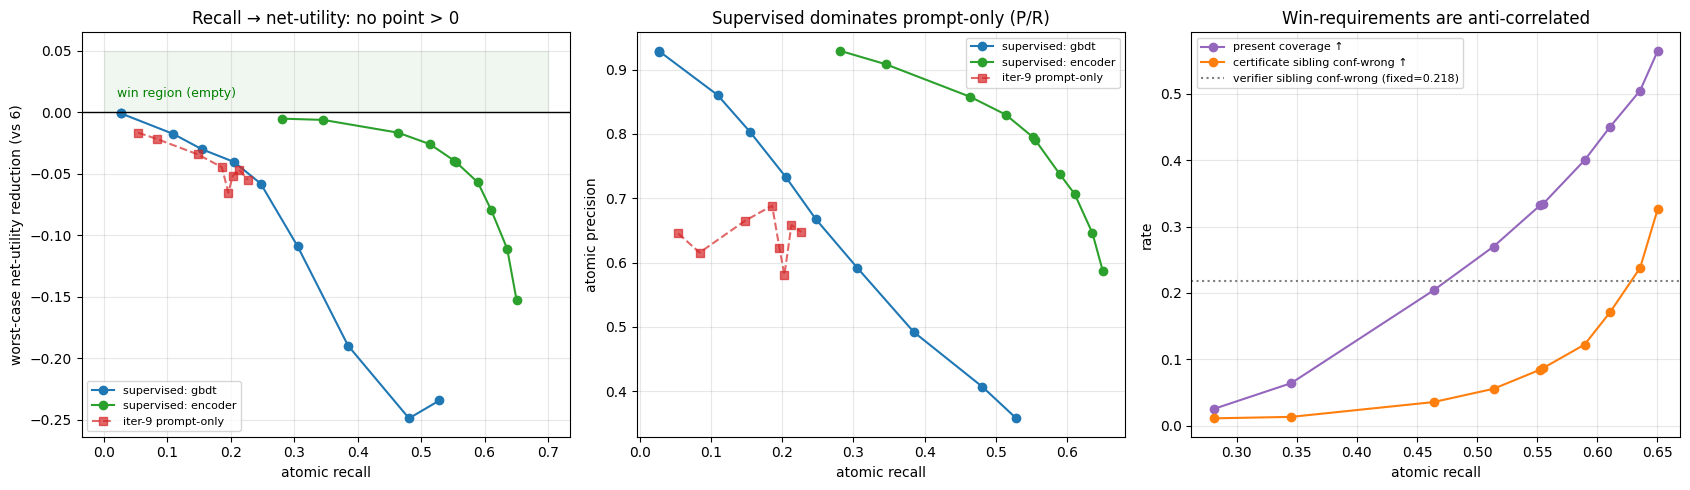

saved frontier_demo.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors = {"gbdt": "tab:blue", "encoder": "tab:green"}

# --- Panel 1: recall -> net-utility reduction ---
ax = axes[0]
for fam in FAMILIES_TO_PLOT:
    rows = sorted(frontier(fam), key=lambda r: r["atomic_recall_canon"])
    x = [r["atomic_recall_canon"] for r in rows]
    y = [r["min_over6_reduction"] for r in rows]
    ax.plot(x, y, "o-", color=colors[fam], label=f"supervised: {fam}")
po = sorted(meta["prompt_only_overlay"]["located_in_frontier"], key=lambda r: r["recall"])
ax.plot([r["recall"] for r in po], [r["min_over6_reduction"] for r in po],
        "s--", color="tab:red", alpha=0.7, label="iter-9 prompt-only")
ax.axhline(0, color="k", lw=1)
ax.fill_between([0, 0.7], 0, 0.05, color="green", alpha=0.06)
ax.text(0.02, 0.012, "win region (empty)", color="green", fontsize=9)
ax.set_xlabel("atomic recall"); ax.set_ylabel("worst-case net-utility reduction (vs 6)")
ax.set_title("Recall → net-utility: no point > 0"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Panel 2: precision-recall frontier ---
ax = axes[1]
for fam in FAMILIES_TO_PLOT:
    rows = sorted(frontier(fam), key=lambda r: r["atomic_recall_canon"])
    ax.plot([r["atomic_recall_canon"] for r in rows],
            [r["atomic_precision_canon"] for r in rows], "o-", color=colors[fam], label=f"supervised: {fam}")
ax.plot([r["recall"] for r in po], [r["precision"] for r in po], "s--", color="tab:red",
        alpha=0.7, label="iter-9 prompt-only")
ax.set_xlabel("atomic recall"); ax.set_ylabel("atomic precision")
ax.set_title("Supervised dominates prompt-only (P/R)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- Panel 3: the anti-correlation (encoder) ---
ax = axes[2]
rows = sorted(frontier("encoder"), key=lambda r: r["atomic_recall_canon"])
x = [r["atomic_recall_canon"] for r in rows]
ax.plot(x, [r["present_coverage"] for r in rows], "o-", color="tab:purple", label="present coverage ↑")
ax.plot(x, [r["absent_sibling_confident_wrong_certificate"] for r in rows], "o-",
        color="tab:orange", label="certificate sibling conf-wrong ↑")
verif = rows[0]["absent_sibling_confident_wrong_verifier"]
ax.axhline(verif, color="tab:gray", ls=":", label=f"verifier sibling conf-wrong (fixed={verif:.3f})")
ax.set_xlabel("atomic recall"); ax.set_ylabel("rate")
ax.set_title("Win-requirements are anti-correlated"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("frontier_demo.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved frontier_demo.png")

In [13]:
# --- Headline ---
fv = meta["fork_verdict"]
syn = fv["decisive_boundary_synthesis"]
gr = meta["gold_read_ceiling"]
print("=" * 78)
print("FORK VERDICT:", fv["overall"])
print("=" * 78)
print(f"best worst-case net-utility reduction over all operating points : {fv['best_worst_case_reduction']:+.4f}  (<= 0 => no flip)")
print(f"max realized atomic recall (supervised)                         : {fv['max_realized_atomic_recall']:.3f}")
print(f"gold-read ceiling (present-cov / abstain / sel-acc)             : "
      f"{gr['present_coverage']:.2f} / {gr['correct_absent_abstention_rate']:.2f} / {gr['present_selective_accuracy_primitive']:.2f}")
print(f"sibling sweet spots (cert < verifier AND reduction >= 0)        : {syn['n_sweet_spots']}")
print(f"verifier sibling confident-wrong (FIXED)                        : {syn['verifier_sibling_confident_wrong']:.3f}")
print(f"  certificate sibling conf-wrong @ high precision (recall {syn['high_precision_point']['recall']:.2f}) : "
      f"{syn['high_precision_point']['certificate_sibling_cw']:.3f}  (present cov only {syn['high_precision_point']['present_coverage']:.3f})")
print(f"  certificate sibling conf-wrong @ high recall    (recall {syn['high_recall_point']['recall']:.2f}) : "
      f"{syn['high_recall_point']['certificate_sibling_cw']:.3f}  (now ABOVE the verifier)")
print()
import textwrap
print(textwrap.fill("SYNTHESIS: " + syn["synthesis"], 96))

FORK VERDICT: NET-UTILITY-BOUNDARY-STRUCTURAL
best worst-case net-utility reduction over all operating points : -0.0010  (<= 0 => no flip)
max realized atomic recall (supervised)                         : 0.650
gold-read ceiling (present-cov / abstain / sel-acc)             : 1.00 / 1.00 / 1.00
sibling sweet spots (cert < verifier AND reduction >= 0)        : 0
verifier sibling confident-wrong (FIXED)                        : 0.218
  certificate sibling conf-wrong @ high precision (recall 0.28) : 0.011  (present cov only 0.025)
  certificate sibling conf-wrong @ high recall    (recall 0.65) : 0.327  (now ABOVE the verifier)

SYNTHESIS: Decisive structural boundary. On the sibling-absent pool the query-side verifier's
confident-wrong is FIXED at ~0.218 (it ignores the extracted graph). The certificate's sibling
confident-wrong is FAR LOWER at high-precision operating points (0.011 at recall 0.281) -- it
abstains structurally -- but present coverage there is only 0.025, so the matched-co